#### Step 1: Import Required Libraries

Start by importing the Python libraries needed for loading, exploring, and visualizing the wine dataset.


In [14]:
import pandas as pd

#### Step 2: Load the Dataset

Read the WineQT dataset into a pandas DataFrame and preview the first few records to confirm that the file loaded correctly.


In [15]:
# read the csv file
df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#### Step 3: Define the Target Variable

The `quality` column is the target variable. It represents the wine quality score and will be used later to compare how different chemical properties relate to wine quality.


#### Step 4: Inspect Dataset Structure

Use `info()` to check column names, data types, row counts, and whether any columns contain missing values.


In [17]:
# 1. Summary of the data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Step 5: Review Summary Statistics

The descriptive statistics help identify the central tendency, spread, and possible unusual ranges in each numeric feature.


In [18]:
# 2. Get the descriptive statistical summary of the dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


#### Step 6: Check Dataset Size

The dataset contains 1,143 rows and 13 columns before any cleaning changes are applied.


In [19]:
# 3. You can look into the shape of the data : i.e number of rows and columns
df.shape

(1143, 13)

#### Step 7: List Available Columns

Reviewing the column names makes it easier to plan feature analysis and confirm that the target column is present.


In [20]:
# 3. You want to see all the columns names
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

#### Step 8: Check Missing Values

This dataset has no missing values, so no imputation or row removal is required for missing data.


In [21]:
# 4. Check for missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

#### Step 9: Inspect Quality Classes

The quality scores range from 3 to 8. This shows that the target is ordinal and has a limited number of classes.


In [22]:
# 5. Lets check what are the unique values in the quality column
sorted_quality_values = df["quality"].unique()
sorted_quality_values

array([5, 6, 7, 4, 8, 3])

#### Step 10: Check and Remove Duplicate Records

Duplicate rows can bias analysis and model training. In this dataset, no duplicate full records are present, so dropping duplicates should not change the row count.


In [26]:
# 6. Check for duplicate records
df.duplicated().sum()
# If you found any duplicates, you can drop them
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

#### Step 11: Calculate Correlations

Correlation helps identify linear relationships between numeric features. Alcohol has the strongest positive relationship with wine quality, while volatile acidity has a noticeable negative relationship.


In [28]:
#  7.  Lets check for the correlation between the variables
# Note : You should only pass the numeric columns
df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


#### Step 12: Visualize the Correlation Matrix

The heatmap makes the correlation patterns easier to compare across all numeric columns. Focus especially on features that correlate with `quality`, such as `alcohol`, `volatile acidity`, `sulphates`, and `citric acid`.


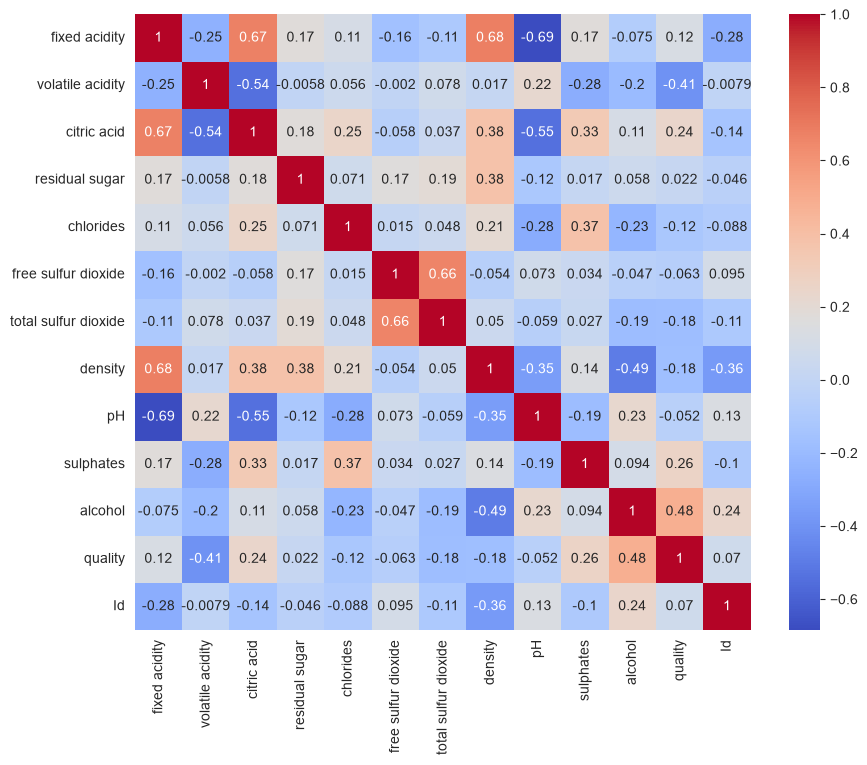

In [33]:
#  lets see the correlation in a visualize manner
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, square=True)
plt.show()

#### Step 13: Check for Outliers

The boxplot helps reveal extreme values across chemical measurements. Features such as residual sugar, chlorides, sulfur dioxide, and sulphates may contain visible outliers that should be considered before modeling.


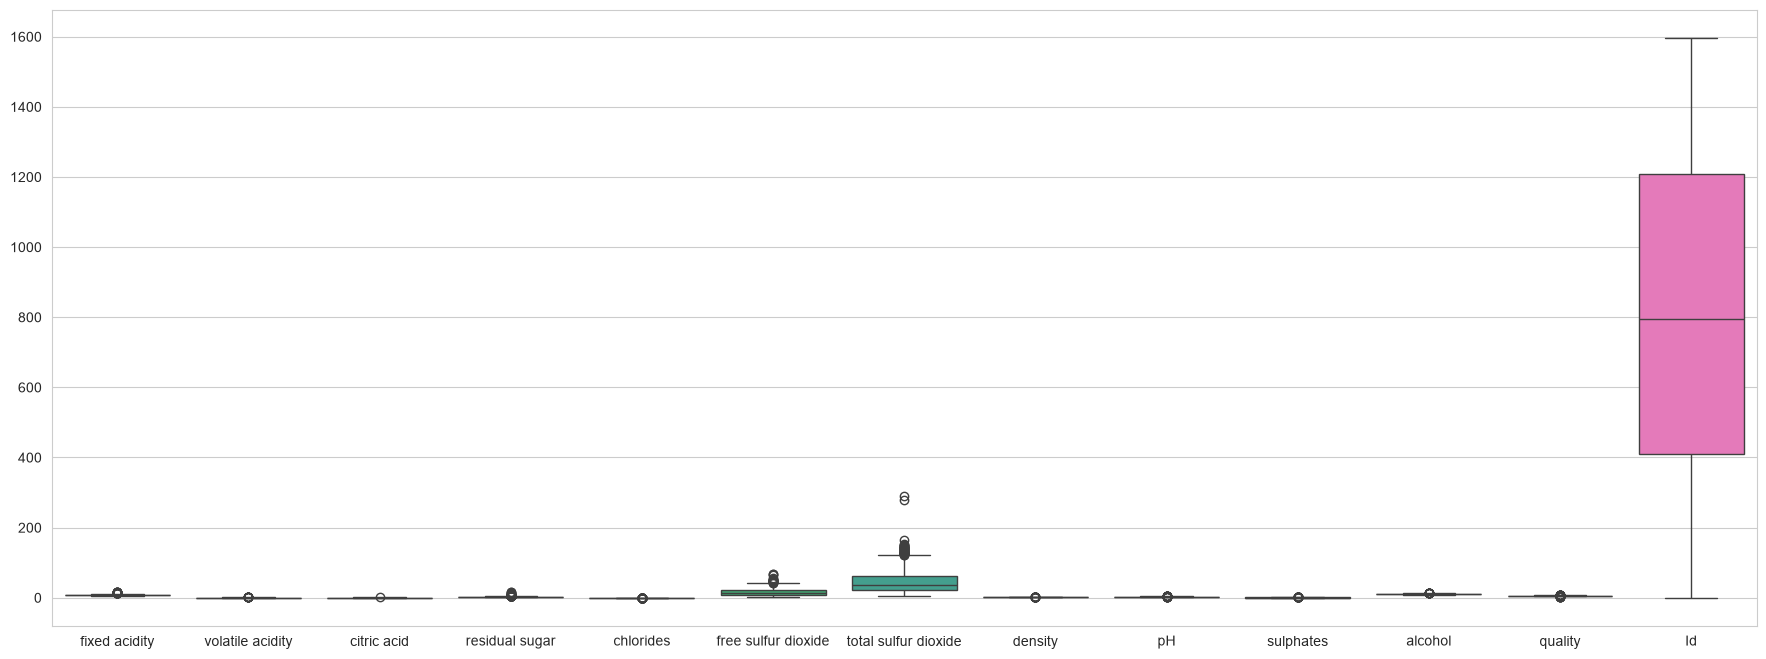

In [39]:
# lets look into outliers in the dataset
plt.figure(figsize=(22, 8))
sns.boxplot(df)
plt.show()

#### Step 14: Check Target Class Balance

Most wines are rated 5 or 6, while very low and very high quality scores are rare. This confirms that the target variable is imbalanced.


In [ ]:
# lets look into if the quality (output variable) is imbalanced or not
df.quality.value_counts()
# Conclusion : As you can see, the quality is imbalanced
#  we can use different techniques to balance the dataset
# - OverSampling - UnderSampling
# SMOTE ( for Numerical Features only )
# SMOTENC ( for both numerical and categorical features )

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

#### Step 15: Visualize Quality Distribution

The bar plot shows the imbalance more clearly. If this dataset is used for classification, evaluation should account for the uneven class distribution.


<Axes: xlabel='quality', ylabel='count'>

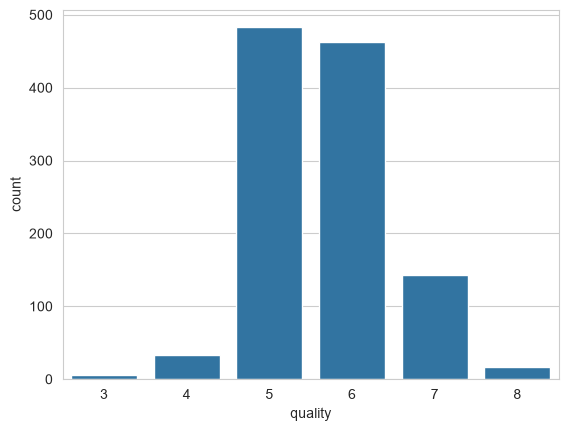

In [43]:
#  lets visualize this using a bar plot
sns.barplot(df["quality"].value_counts())

#### Step 16: Compare Feature Distributions

KDE plots help compare the shape and spread of numeric features. Here, fixed acidity and alcohol have different distribution patterns, which may affect scaling decisions before modeling.


<Axes: xlabel='fixed acidity', ylabel='Density'>

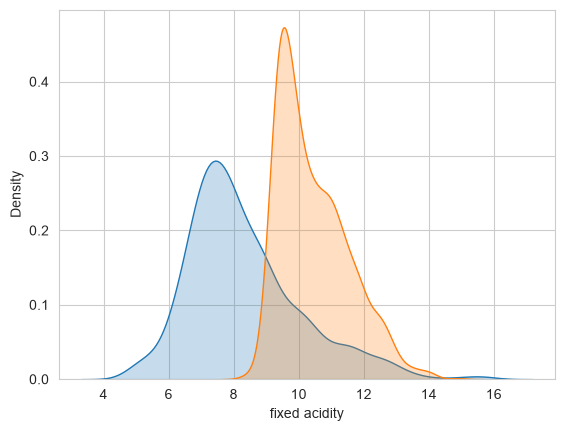

In [ ]:
#  to see the distribution of some numerical columns
sns.kdeplot(df["fixed acidity"], fill=True)
sns.kdeplot(df["alcohol"], fill=True)

#### Step 17: Analyze Alcohol by Quality

Alcohol tends to increase as wine quality increases. This supports the positive correlation observed earlier between `alcohol` and `quality`.


<Axes: xlabel='quality', ylabel='alcohol'>

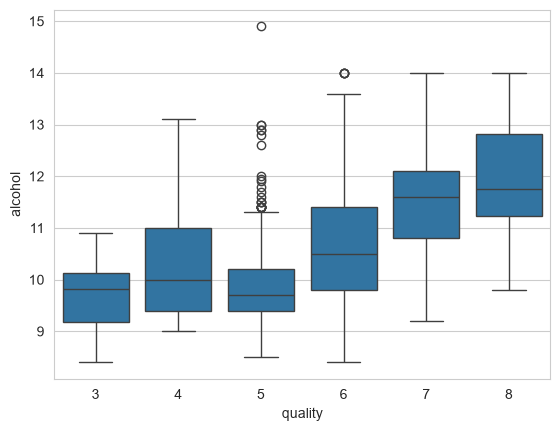

In [ ]:
from pandas.core.col import col

# let see the quality vs alcohol
sns.boxplot(data=df, x="quality", y="alcohol")

#### Step 18: Explore pH, Alcohol, and Quality Together

The scatter plot compares pH and alcohol while coloring points by quality. Alcohol appears more informative for separating quality levels than pH.


<Axes: xlabel='pH', ylabel='alcohol'>

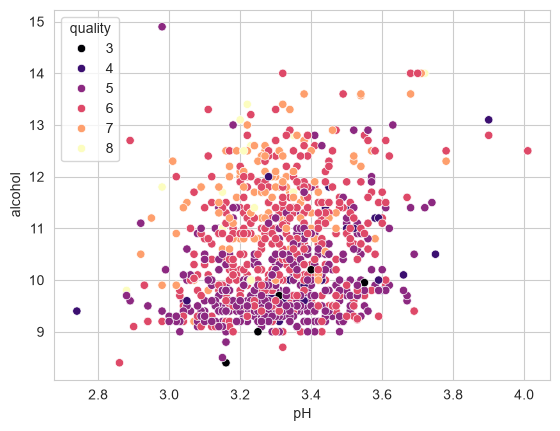

In [ ]:
sns.scatterplot(data=df, x="pH", y="alcohol", hue="quality", palette="magma")

#### Step 19: Final EDA Conclusions

- The dataset is clean with no missing values and no duplicate full records.
- Wine quality is imbalanced, with most samples rated 5 or 6.
- Alcohol is the strongest positive indicator of quality in this analysis.
- Volatile acidity has a meaningful negative relationship with quality.
- Several numeric features show possible outliers, so outlier handling and feature scaling should be considered before model building.
